# **1. Perkenalan Dataset**


Dataset yang digunakan adalah **Students Exam Performance** yang tersedia secara publik di Kaggle.

**Sumber Dataset**: [Students Performance in Exams – Kaggle](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)

**Deskripsi Dataset**:
Dataset ini berisi informasi tentang performa siswa pada ujian matematika, membaca, dan menulis. Terdapat beberapa fitur demografis dan latar belakang siswa yang dapat digunakan untuk memprediksi hasil ujian mereka.

**Fitur-fitur dalam dataset:**
- `gender`: Jenis kelamin siswa (male/female)
- `race/ethnicity`: Kelompok etnis siswa
- `parental level of education`: Tingkat pendidikan orang tua
- `lunch`: Jenis makan siang (standard/free or reduced)
- `test preparation course`: Apakah siswa mengikuti kursus persiapan ujian
- `math score`: Nilai ujian matematika (0–100)
- `reading score`: Nilai ujian membaca (0–100)
- `writing score`: Nilai ujian menulis (0–100)

**Target/Label**: `pass_math` — apakah siswa lulus ujian matematika (score ≥ 60 → **lulus**, score < 60 → **tidak lulus**). Ini adalah **klasifikasi biner**.


# **2. Import Library**

Pada tahap ini, kita mengimpor pustaka Python yang dibutuhkan untuk analisis data, visualisasi, preprocessing, pemodelan, dan evaluasi model machine learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

print("Library berhasil diimpor!")

Library berhasil diimpor!


# **3. Memuat Dataset**

Dataset dimuat menggunakan `pandas.read_csv()`. Kita juga menampilkan beberapa baris awal untuk memahami struktur data.

In [ ]:
df = pd.read_csv("student_exam_performance.csv")
print(f"Ukuran dataset: {df.shape[0]} baris x {df.shape[1]} kolom")
df.head()

Ukuran dataset: 1000 baris x 8 kolom


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group A,high school,standard,completed,67,67,63
1,female,group D,some high school,free/reduced,none,40,59,55
2,male,group E,some college,free/reduced,none,59,60,50
3,male,group B,high school,standard,none,77,78,68
4,male,group E,associate's degree,standard,completed,78,73,68


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, kita akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset secara mendalam sebelum melakukan pemodelan.

In [ ]:
# Informasi umum dataset
print("=== Informasi Dataset ===")
df.info()

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
# Statistik deskriptif
print("=== Statistik Deskriptif ===")
df.describe()

=== Statistik Deskriptif ===


,math score,reading score,writing score
count,1000.000000,1000.000000,1000.000000
mean,66.396000,69.002000,67.738000
std,15.402871,14.737272,15.600985
min,13.000000,27.000000,23.000000
25%,56.000000,60.000000,58.000000
50%,66.500000,70.000000,68.000000
75%,77.000000,79.000000,79.000000
max,100.000000,100.000000,100.000000


In [ ]:
# Cek missing value
print("=== Missing Values ===")
print(df.isnull().sum())
print("\nTotal missing value:", df.isnull().sum().sum())

=== Missing Values ===
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Total missing value: 0


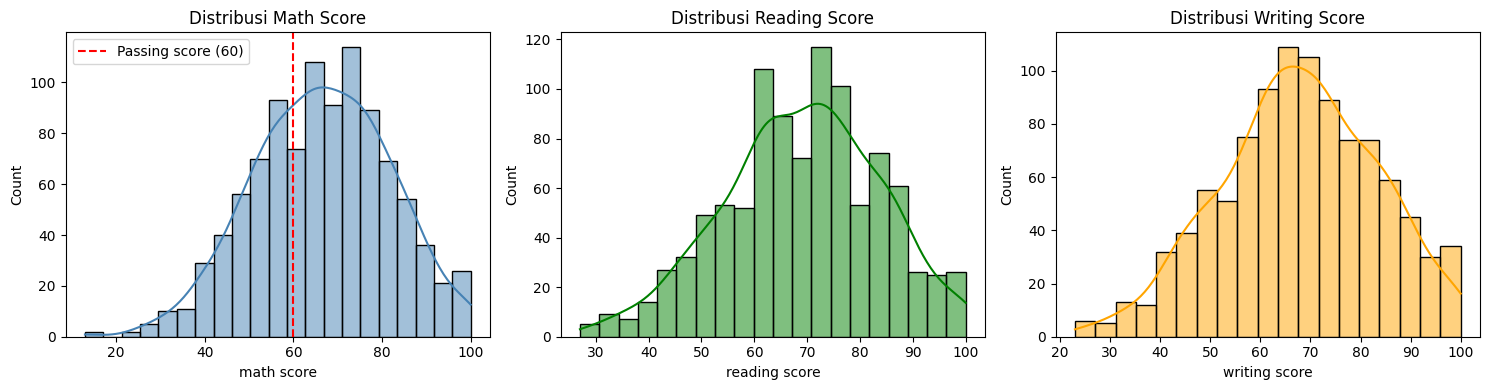

In [ ]:
# Visualisasi distribusi math score
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df["math score"], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title("Distribusi Math Score")
axes[0].axvline(60, color='red', linestyle='--', label='Passing score (60)')
axes[0].legend()

sns.histplot(df["reading score"], kde=True, ax=axes[1], color='green')
axes[1].set_title("Distribusi Reading Score")

sns.histplot(df["writing score"], kde=True, ax=axes[2], color='orange')
axes[2].set_title("Distribusi Writing Score")

plt.tight_layout()
plt.show()

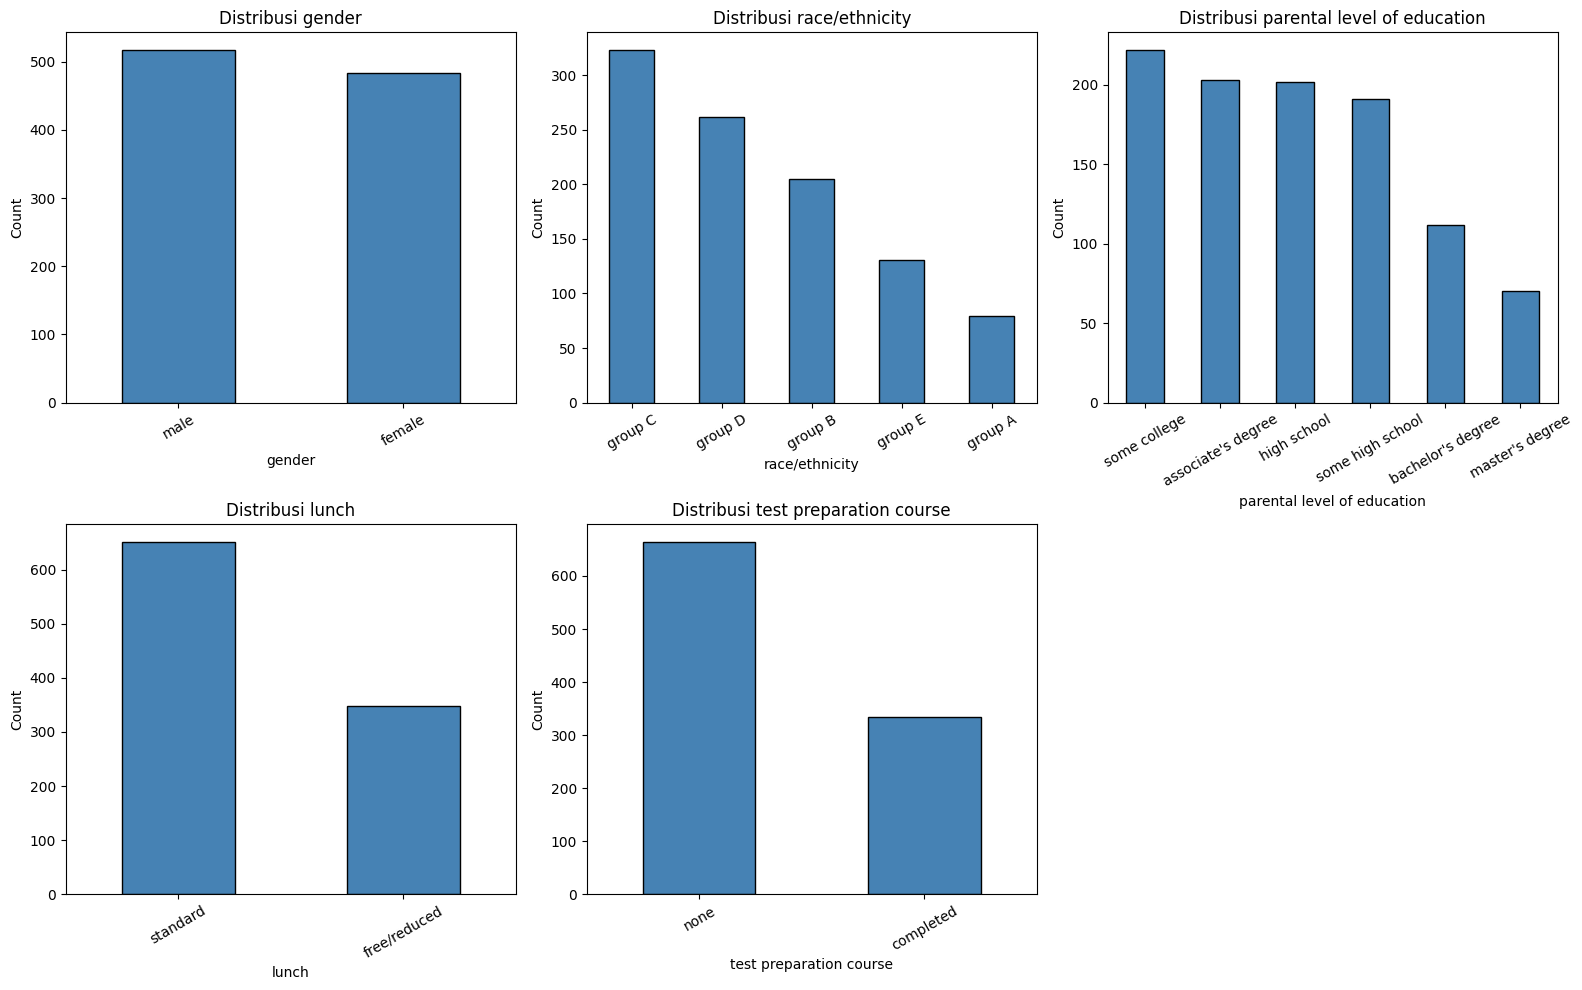

In [ ]:
# Visualisasi distribusi fitur kategorikal
categorical_cols = ['gender', 'race/ethnicity', 'parental level of education',
                    'lunch', 'test preparation course']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)

# Sembunyikan subplot kosong
axes[5].set_visible(False)
plt.tight_layout()
plt.show()

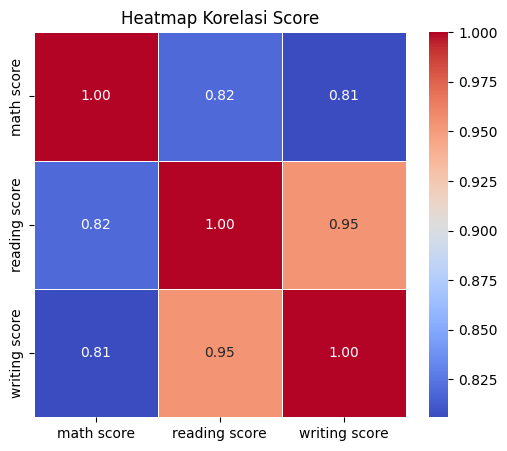

In [ ]:
# Heatmap korelasi antar nilai
plt.figure(figsize=(6, 5))
corr = df[['math score', 'reading score', 'writing score']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Score')
plt.show()

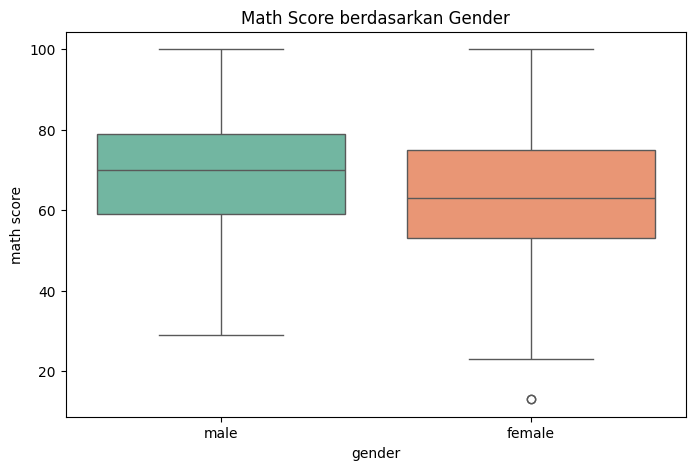

In [ ]:
# Boxplot math score berdasarkan gender
plt.figure(figsize=(8, 5))
sns.boxplot(x='gender', y='math score', data=df, palette='Set2')
plt.title('Math Score berdasarkan Gender')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini dilakukan pembersihan dan transformasi data sebelum digunakan untuk pemodelan.

**Langkah preprocessing yang dilakukan:**
1. Membuat label target (`pass_math`)
2. Encoding fitur kategorikal dengan Label Encoding
3. Memisahkan fitur (X) dan target (y)
4. Split data: train (80%) dan test (20%)
5. Standarisasi fitur numerik

In [ ]:
# 1. Membuat label target: pass_math (1 = lulus, 0 = tidak lulus)
df['pass_math'] = (df['math score'] >= 60).astype(int)

print("Distribusi label target 'pass_math':")
print(df['pass_math'].value_counts())
print()
print(f"Lulus (1): {df['pass_math'].sum()} siswa")
print(f"Tidak lulus (0): {(df['pass_math']==0).sum()} siswa")

Distribusi label target 'pass_math':
pass_math
1    665
0    335
Name: count, dtype: int64

Lulus (1): 665 siswa
Tidak lulus (0): 335 siswa


In [ ]:
# 2. Encoding fitur kategorikal dengan Label Encoding
df_processed = df.copy()

categorical_cols = ['gender', 'race/ethnicity', 'parental level of education',
                    'lunch', 'test preparation course']

le = LabelEncoder()
for col in categorical_cols:
    df_processed[col] = le.fit_transform(df_processed[col])

print("Encoding selesai. Preview data:")
df_processed.head()

Encoding selesai. Preview data:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,pass_math
0,1,0,2,1,0,67,67,63,1
1,0,3,5,0,1,40,59,55,0
2,1,4,4,0,1,59,60,50,0
3,1,1,2,1,1,77,78,68,1
4,1,4,0,1,0,78,73,68,1


In [ ]:
# 3. Pisahkan fitur (X) dan target (y)
# Hapus 'math score' dari fitur agar tidak bocor ke model (target berasal dari kolom ini)
X = df_processed.drop(columns=['math score', 'pass_math'])
y = df_processed['pass_math']

print("Fitur yang digunakan:", list(X.columns))
print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")

Fitur yang digunakan: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'reading score', 'writing score']
Shape X: (1000, 7)
Shape y: (1000,)


In [ ]:
# 4. Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Ukuran data training: {X_train.shape}")
print(f"Ukuran data testing : {X_test.shape}")

Ukuran data training: (800, 7)
Ukuran data testing : (200, 7)


In [ ]:
# 5. Standarisasi fitur numerik
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Standarisasi selesai.")
print(f"Mean fitur (training): {X_train_scaled.mean(axis=0).round(4)}")
df_processed.to_csv("student_exam_preprocessed.csv", index=False)
print(df_processed.shape)
df_processed.head()

Standarisasi selesai.
Mean fitur (training): [ 0.  0.  0. -0.  0. -0. -0.]
(1000, 9)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,pass_math
0,1,0,2,1,0,67,67,63,1
1,0,3,5,0,1,40,59,55,0
2,1,4,4,0,1,59,60,50,0
3,1,1,2,1,1,77,78,68,1
4,1,4,0,1,0,78,73,68,1


# **6. Modeling**

Pada tahap ini, kita melatih dua model klasifikasi:
1. **Logistic Regression** — model linear yang sederhana dan interpretatif
2. **Random Forest Classifier** — model ensemble berbasis decision tree

Kedua model dilatih menggunakan data training yang sudah distandarisasi.

In [ ]:
# Model 1: Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=200)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)

print("=== Logistic Regression ===")
print(f"Akurasi: {acc_lr:.4f} ({acc_lr*100:.2f}%)")

=== Logistic Regression ===
Akurasi: 0.8900 (89.00%)


In [ ]:
# Model 2: Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("=== Random Forest Classifier ===")
print(f"Akurasi: {acc_rf:.4f} ({acc_rf*100:.2f}%)")

=== Random Forest Classifier ===
Akurasi: 0.8750 (87.50%)


# **7. Evaluation**

Evaluasi model dilakukan menggunakan:
- **Accuracy Score**: Persentase prediksi yang benar
- **Classification Report**: Precision, Recall, F1-Score per kelas
- **Confusion Matrix**: Visualisasi distribusi prediksi benar dan salah

In [ ]:
# Evaluasi Logistic Regression
print("========================================")
print("     EVALUASI: LOGISTIC REGRESSION      ")
print("========================================")
print(f"Akurasi       : {acc_lr*100:.2f}%")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_lr,
                             target_names=['Tidak Lulus (0)', 'Lulus (1)']))

     EVALUASI: LOGISTIC REGRESSION      
Akurasi       : 89.00%

Classification Report:
                 precision    recall  f1-score   support

Tidak Lulus (0)       0.86      0.81      0.83        67
      Lulus (1)       0.91      0.93      0.92       133

       accuracy                           0.89       200
      macro avg       0.88      0.87      0.87       200
   weighted avg       0.89      0.89      0.89       200



In [ ]:
# Evaluasi Random Forest
print("========================================")
print("    EVALUASI: RANDOM FOREST CLASSIFIER  ")
print("========================================")
print(f"Akurasi       : {acc_rf*100:.2f}%")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_rf,
                             target_names=['Tidak Lulus (0)', 'Lulus (1)']))

    EVALUASI: RANDOM FOREST CLASSIFIER  
Akurasi       : 87.50%

Classification Report:
                 precision    recall  f1-score   support

Tidak Lulus (0)       0.83      0.79      0.81        67
      Lulus (1)       0.90      0.92      0.91       133

       accuracy                           0.88       200
      macro avg       0.86      0.85      0.86       200
   weighted avg       0.87      0.88      0.87       200



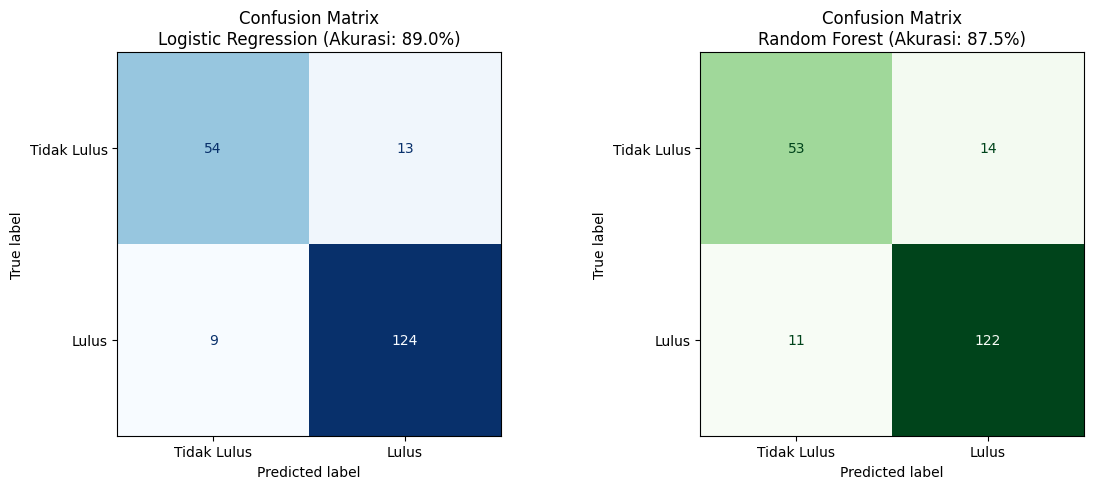

In [ ]:
# Confusion Matrix untuk kedua model
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                                  display_labels=['Tidak Lulus', 'Lulus'])
disp_lr.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix\nLogistic Regression (Akurasi: {acc_lr*100:.1f}%)')

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                                  display_labels=['Tidak Lulus', 'Lulus'])
disp_rf.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f'Confusion Matrix\nRandom Forest (Akurasi: {acc_rf*100:.1f}%)')

plt.tight_layout()
plt.show()

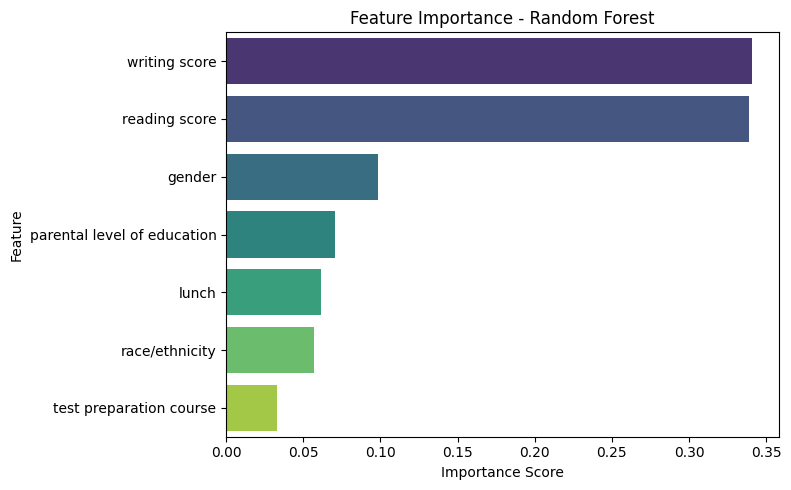

                    Feature  Importance
              writing score    0.340946
              reading score    0.338557
                     gender    0.098543
parental level of education    0.070533
                      lunch    0.061530
             race/ethnicity    0.057075
    test preparation course    0.032816


In [ ]:
# Feature Importance dari Random Forest
feature_names = X.columns.tolist()
importances = rf_model.feature_importances_

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(fi_df.to_string(index=False))

In [ ]:
# Ringkasan perbandingan model
print("==========================================")
print("       RINGKASAN PERBANDINGAN MODEL       ")
print("==========================================")
print(f"{'Model':<30} {'Akurasi':>10}")
print("-" * 42)
print(f"{'Logistic Regression':<30} {acc_lr*100:>9.2f}%")
print(f"{'Random Forest Classifier':<30} {acc_rf*100:>9.2f}%")
print("==========================================")
best_model = "Random Forest" if acc_rf > acc_lr else "Logistic Regression"
print(f"\nModel terbaik: {best_model}")

       RINGKASAN PERBANDINGAN MODEL       
Model                             Akurasi
------------------------------------------
Logistic Regression                89.00%
Random Forest Classifier           87.50%

Model terbaik: Logistic Regression
